# 2D TUnfold Notebook for Jet Mass

This notebook performs a self-contained 2D unfolding in generator $p_T$ blocks with mass as the lowest-level axis inside each block.

It uses `hist` objects as inputs, converts them to numpy arrays, and then builds the unfolding problem with `ROOT.TUnfoldDensity` plus `ROOT.TUnfoldBinning`.

Input contract:
- response histogram
- generator histogram
- reconstructed histogram
- fakes are derived as reco minus the reco-side projection of the response
- misses are derived as gen minus the gen-side projection of the response

Requested response projection convention:

```python
response_hist = out["response_matrix_u"].project("ptreco", "mreco", "ptgen", "mgen")
response_values = np.asarray(response_hist.values())
```

The same measured reco spectrum is unfolded twice:
- once with the Pythia response
- once with the Herwig response

Regularisation modes exposed in this notebook:
- `none`
- `scan_tau`
- `scan_lcurve`

The defaults point to the combined mass input pickles already present in this repository.

## 0 — Configuration

In [2]:
OBS = "u"

INPUT_FILES = {
    "pythia": "inputs/massInputs/fine_bin/mass_pythia_2016.pkl",
    "herwig": "inputs/massInputs/fine_bin/mass_herwig_2016.pkl",
    "data": "inputs/massInputs/fine_bin/mass_data_2016.pkl",
}

REGULARIZATION_MODE = "scan_lcurve"
FIXED_TAU = 0.0
SCAN_N_POINTS = 40
SCAN_TAU_MIN = 1e-6
SCAN_TAU_MAX = 1.0

USE_FAKE_BACKGROUND_SUBTRACTION = True
NORMALIZE_SHAPE_PLOTS = True
PLOT_OBSERVABLE_LABEL = "Jet mass [GeV]"
MODEL_ORDER = ("pythia", "herwig")

MODE_ALIASES = {
    "none": "none",
    "no regularisation": "none",
    "no_regularisation": "none",
    "scan tau": "scan_tau",
    "scan_tau": "scan_tau",
    "scantau": "scan_tau",
    "scan lcurve": "scan_lcurve",
    "scan_lcurve": "scan_lcurve",
    "scanlcurve": "scan_lcurve",
}

print(f"Observable: {'ungroomed' if OBS == 'u' else 'groomed'} mass")
print("Input files:")
for name, path in INPUT_FILES.items():
    print(f"  {name:>6}: {path}")
print(f"Regularization mode: {REGULARIZATION_MODE}")
print(f"Fixed tau: {FIXED_TAU}")
print(f"Subtract fake background: {USE_FAKE_BACKGROUND_SUBTRACTION}")

Observable: ungroomed mass
Input files:
  pythia: inputs/massInputs/fine_bin/mass_pythia_2016.pkl
  herwig: inputs/massInputs/fine_bin/mass_herwig_2016.pkl
    data: inputs/massInputs/fine_bin/mass_data_2016.pkl
Regularization mode: scan_lcurve
Fixed tau: 0.0
Subtract fake background: True


## 1 — Imports and Repo Root

In [3]:
from array import array
from pathlib import Path
import pickle

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import ROOT

ROOT.gROOT.SetBatch(True)
ROOT.TH1.SetDefaultSumw2()

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "pythia": "#1f77b4",
    "herwig": "#d62728",
    "data": "#111111",
}


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "inputs").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from the current working directory.")


REPO_ROOT = find_repo_root()
print("Repo root:", REPO_ROOT)
print("ROOT version:", ROOT.__version__)
print("numpy version:", np.__version__)

Repo root: /mnt/8A04C21E04C20CDF/wsLinux/unfold
ROOT version: 6.38.04
numpy version: 2.4.3


## 2 — Load Input Pickles

In [4]:
def resolve_repo_path(path_str: str) -> Path:
    path = Path(path_str)
    return path if path.is_absolute() else REPO_ROOT / path


def load_pickle(path_str: str) -> dict:
    path = resolve_repo_path(path_str)
    with path.open("rb") as handle:
        return pickle.load(handle)


def select_nominal_if_present(hist_obj):
    axis_names = [axis.name for axis in hist_obj.axes]
    if "systematic" in axis_names and "nominal" in list(hist_obj.axes["systematic"]):
        return hist_obj[{"systematic": "nominal"}]
    return hist_obj


loaded_inputs = {name: load_pickle(path) for name, path in INPUT_FILES.items()}

response_key = f"response_matrix_{OBS}"
gen_key = f"ptjet_mjet_{OBS}_gen"
reco_key = f"ptjet_mjet_{OBS}_reco"

pythia_response_hist = select_nominal_if_present(loaded_inputs["pythia"][response_key])
pythia_gen_hist = select_nominal_if_present(loaded_inputs["pythia"][gen_key])
pythia_reco_hist = select_nominal_if_present(loaded_inputs["pythia"][reco_key])

herwig_response_hist = select_nominal_if_present(loaded_inputs["herwig"][response_key])
herwig_gen_hist = select_nominal_if_present(loaded_inputs["herwig"][gen_key])
herwig_reco_hist = select_nominal_if_present(loaded_inputs["herwig"][reco_key])

data_reco_hist = select_nominal_if_present(loaded_inputs["data"][reco_key])

print("Loaded keys:")
print("  pythia:", sorted(loaded_inputs["pythia"].keys()))
print("  herwig:", sorted(loaded_inputs["herwig"].keys()))
print("  data  :", sorted(loaded_inputs["data"].keys()))

Loaded keys:
  pythia: ['cutflow', 'nev', 'ptjet_mjet_g_gen', 'ptjet_mjet_g_reco', 'ptjet_mjet_u_gen', 'ptjet_mjet_u_reco', 'ptz_mz_reco', 'response_matrix_g', 'response_matrix_u', 'sumw']
  herwig: ['cutflow', 'nev', 'ptjet_mjet_g_gen', 'ptjet_mjet_g_reco', 'ptjet_mjet_u_gen', 'ptjet_mjet_u_reco', 'ptz_mz_reco', 'response_matrix_g', 'response_matrix_u', 'sumw']
  data  : ['cutflow', 'nev', 'ptjet_mjet_g_reco', 'ptjet_mjet_u_reco', 'sumw']


## 3 — Helpers for Projection, Flattening, and Validation

In [5]:
def normalize_regularization_mode(mode: str) -> str:
    key = mode.strip().lower().replace("-", " ").replace("_", " ")
    if key not in MODE_ALIASES:
        raise ValueError(
            f"Unsupported regularization mode '{mode}'. Choose from {sorted(set(MODE_ALIASES.values()))}."
        )
    return MODE_ALIASES[key]


def assert_axes_present(hist_obj, required_axes: tuple[str, ...]) -> None:
    available = {axis.name for axis in hist_obj.axes}
    missing = [axis for axis in required_axes if axis not in available]
    if missing:
        raise KeyError(f"Histogram is missing axes {missing}. Available axes: {sorted(available)}")


def project_values(hist_obj, *axis_names: str):
    projected = hist_obj.project(*axis_names)
    values = np.asarray(projected.values(flow=False), dtype=float)
    variances = projected.variances(flow=False)
    if variances is not None:
        variances = np.asarray(variances, dtype=float)
    return projected, values, variances


def flatten_pt_mass(values_2d: np.ndarray) -> np.ndarray:
    return np.asarray(values_2d, dtype=float).reshape(-1)


def unflatten_pt_mass(values_flat: np.ndarray, n_pt: int, n_mass: int) -> np.ndarray:
    return np.asarray(values_flat, dtype=float).reshape(n_pt, n_mass)


def variances_to_errors(values: np.ndarray, variances: np.ndarray | None) -> np.ndarray:
    if variances is None:
        return np.sqrt(np.clip(values, 0.0, None))
    return np.sqrt(np.clip(variances, 0.0, None))


def require_same_edges(reference: np.ndarray, candidate: np.ndarray, label: str) -> None:
    if not np.allclose(reference, candidate):
        raise ValueError(f"Binning mismatch for {label}.")


def tgraph_to_arrays(graph) -> tuple[np.ndarray, np.ndarray] | None:
    if not graph:
        return None
    n_points = graph.GetN()
    x_values = np.array([graph.GetPointX(index) for index in range(n_points)], dtype=float)
    y_values = np.array([graph.GetPointY(index) for index in range(n_points)], dtype=float)
    return x_values, y_values


def sample_spline(spline, xmin: float, xmax: float, n_points: int = 200) -> tuple[np.ndarray, np.ndarray] | None:
    if not spline:
        return None
    x_values = np.linspace(xmin, xmax, n_points)
    y_values = np.array([spline.Eval(float(x_value)) for x_value in x_values], dtype=float)
    return x_values, y_values


REGULARIZATION_MODE = normalize_regularization_mode(REGULARIZATION_MODE)
print("Normalized regularization mode:", REGULARIZATION_MODE)

Normalized regularization mode: scan_lcurve


In [6]:
def build_model_inputs(model_name: str, response_hist, gen_hist, reco_hist) -> dict:
    assert_axes_present(response_hist, ("ptreco", "mreco", "ptgen", "mgen"))
    assert_axes_present(gen_hist, ("ptgen", "mgen"))
    assert_axes_present(reco_hist, ("ptreco", "mreco"))

    response_proj, response_values, _ = project_values(
        response_hist,
        "ptreco",
        "mreco",
        "ptgen",
        "mgen",
    )
    reco_proj, reco_values, reco_variances = project_values(reco_hist, "ptreco", "mreco")
    gen_proj, gen_values, gen_variances = project_values(gen_hist, "ptgen", "mgen")

    ptreco_edges = np.asarray(response_proj.axes["ptreco"].edges, dtype=float)
    mreco_edges = np.asarray(response_proj.axes["mreco"].edges, dtype=float)
    ptgen_edges = np.asarray(response_proj.axes["ptgen"].edges, dtype=float)
    mgen_edges = np.asarray(response_proj.axes["mgen"].edges, dtype=float)

    require_same_edges(ptreco_edges, np.asarray(reco_proj.axes["ptreco"].edges, dtype=float), f"{model_name} reco pt")
    require_same_edges(mreco_edges, np.asarray(reco_proj.axes["mreco"].edges, dtype=float), f"{model_name} reco mass")
    require_same_edges(ptgen_edges, np.asarray(gen_proj.axes["ptgen"].edges, dtype=float), f"{model_name} gen pt")
    require_same_edges(mgen_edges, np.asarray(gen_proj.axes["mgen"].edges, dtype=float), f"{model_name} gen mass")

    matched_reco = response_values.sum(axis=(2, 3))
    matched_gen = response_values.sum(axis=(0, 1))

    fakes_values = np.clip(reco_values - matched_reco, 0.0, None)
    misses_values = np.clip(gen_values - matched_gen, 0.0, None)

    n_ptreco, n_mreco, n_ptgen, n_mgen = response_values.shape

    return {
        "name": model_name,
        "response_hist": response_hist,
        "gen_hist": gen_hist,
        "reco_hist": reco_hist,
        "response_4d": response_values,
        "response_2d": response_values.reshape(n_ptreco * n_mreco, n_ptgen * n_mgen),
        "reco_2d": reco_values,
        "reco_2d_errors": variances_to_errors(reco_values, reco_variances),
        "gen_2d": gen_values,
        "gen_2d_errors": variances_to_errors(gen_values, gen_variances),
        "matched_reco_2d": matched_reco,
        "matched_gen_2d": matched_gen,
        "fakes_2d": fakes_values,
        "misses_2d": misses_values,
        "reco_flat": flatten_pt_mass(reco_values),
        "gen_flat": flatten_pt_mass(gen_values),
        "fakes_flat": flatten_pt_mass(fakes_values),
        "misses_flat": flatten_pt_mass(misses_values),
        "ptreco_edges": ptreco_edges,
        "mreco_edges": mreco_edges,
        "ptgen_edges": ptgen_edges,
        "mgen_edges": mgen_edges,
        "reco_mass_edges_by_pt": [mreco_edges.copy() for _ in range(n_ptreco)],
        "gen_mass_edges_by_pt": [mgen_edges.copy() for _ in range(n_ptgen)],
        "n_ptreco": n_ptreco,
        "n_mreco": n_mreco,
        "n_ptgen": n_ptgen,
        "n_mgen": n_mgen,
    }


pythia_inputs = build_model_inputs("pythia", pythia_response_hist, pythia_gen_hist, pythia_reco_hist)
herwig_inputs = build_model_inputs("herwig", herwig_response_hist, herwig_gen_hist, herwig_reco_hist)

require_same_edges(pythia_inputs["ptreco_edges"], herwig_inputs["ptreco_edges"], "model reco pt")
require_same_edges(pythia_inputs["mreco_edges"], herwig_inputs["mreco_edges"], "model reco mass")
require_same_edges(pythia_inputs["ptgen_edges"], herwig_inputs["ptgen_edges"], "model gen pt")
require_same_edges(pythia_inputs["mgen_edges"], herwig_inputs["mgen_edges"], "model gen mass")

_, data_reco_values, data_reco_variances = project_values(data_reco_hist, "ptreco", "mreco")
data_reco_errors = variances_to_errors(data_reco_values, data_reco_variances)

data_ptreco_edges = np.asarray(data_reco_hist.project("ptreco", "mreco").axes["ptreco"].edges, dtype=float)
data_mreco_edges = np.asarray(data_reco_hist.project("ptreco", "mreco").axes["mreco"].edges, dtype=float)
require_same_edges(pythia_inputs["ptreco_edges"], data_ptreco_edges, "data reco pt")
require_same_edges(pythia_inputs["mreco_edges"], data_mreco_edges, "data reco mass")

models = {
    "pythia": pythia_inputs,
    "herwig": herwig_inputs,
}

data_reco_flat = flatten_pt_mass(data_reco_values)
data_reco_errors_flat = flatten_pt_mass(data_reco_errors)

print("Prepared inputs:")
for model_name in MODEL_ORDER:
    model = models[model_name]
    print(
        f"  {model_name:>6}: response {model['response_2d'].shape}, "
        f"fakes={model['fakes_flat'].sum():.2f}, misses={model['misses_flat'].sum():.2f}"
    )
print("  data  :", data_reco_values.shape, f"total={data_reco_flat.sum():.2f}")

Prepared inputs:
  pythia: response (852, 424), fakes=962.01, misses=21708.25
  herwig: response (852, 424), fakes=1.74, misses=38.16
  data  : (4, 213) total=44565.00


## 4 — ROOT and TUnfold Helpers

In [7]:
def build_root_binning(gen_mass_edges_by_pt: list[np.ndarray], reco_mass_edges_by_pt: list[np.ndarray]):
    truth_root = ROOT.TUnfoldBinning("truth")
    reco_root = ROOT.TUnfoldBinning("reco")

    truth_signal = truth_root.AddBinning("signal")
    reco_primary = reco_root.AddBinning("primary")

    for index, edges in enumerate(gen_mass_edges_by_pt):
        node = truth_signal.AddBinning(f"pt{index}")
        node.AddAxis("mass", len(edges) - 1, array("d", np.asarray(edges, dtype=float)), False, False)

    for index, edges in enumerate(reco_mass_edges_by_pt):
        node = reco_primary.AddBinning(f"pt{index}")
        node.AddAxis("mass", len(edges) - 1, array("d", np.asarray(edges, dtype=float)), False, False)

    return truth_root, reco_root


def fill_root_histogram(root_hist, values: np.ndarray, errors: np.ndarray | None = None) -> None:
    values = np.asarray(values, dtype=float)
    if errors is None:
        errors = np.sqrt(np.clip(values, 0.0, None))
    for index, value in enumerate(values, start=1):
        root_hist.SetBinContent(index, float(value))
        root_hist.SetBinError(index, float(errors[index - 1]))


def fill_response_histogram(root_hist, response_2d: np.ndarray, misses_flat: np.ndarray) -> None:
    n_reco, n_truth = response_2d.shape
    for reco_index in range(n_reco):
        for truth_index in range(n_truth):
            root_hist.SetBinContent(truth_index + 1, reco_index + 1, float(response_2d[reco_index, truth_index]))
    for truth_index in range(n_truth):
        root_hist.SetBinContent(truth_index + 1, 0, float(misses_flat[truth_index]))


def extract_th1(root_hist) -> tuple[np.ndarray, np.ndarray]:
    n_bins = root_hist.GetNbinsX()
    values = np.array([root_hist.GetBinContent(index) for index in range(1, n_bins + 1)], dtype=float)
    errors = np.array([root_hist.GetBinError(index) for index in range(1, n_bins + 1)], dtype=float)
    return values, errors


def extract_th2(root_hist) -> np.ndarray:
    n_x = root_hist.GetNbinsX()
    n_y = root_hist.GetNbinsY()
    return np.array(
        [[root_hist.GetBinContent(ix + 1, iy + 1) for iy in range(n_y)] for ix in range(n_x)],
        dtype=float,
    )


def build_model_corrected_measurement(measured_flat: np.ndarray, fake_flat: np.ndarray) -> np.ndarray:
    corrected = np.asarray(measured_flat, dtype=float) - np.asarray(fake_flat, dtype=float)
    return np.clip(corrected, 0.0, None)


def run_unfold(
    model_inputs: dict,
    measured_flat: np.ndarray,
    measured_errors_flat: np.ndarray,
    regularization_mode: str,
    fixed_tau: float,
    scan_n_points: int,
    scan_tau_min: float,
    scan_tau_max: float,
    subtract_fake_background: bool,
) -> dict:
    truth_root, reco_root = build_root_binning(
        model_inputs["gen_mass_edges_by_pt"],
        model_inputs["reco_mass_edges_by_pt"],
    )

    h_response = ROOT.TUnfoldBinning.CreateHistogramOfMigrations(
        truth_root,
        reco_root,
        f"hResponse_{model_inputs['name']}"
    )
    fill_response_histogram(h_response, model_inputs["response_2d"], model_inputs["misses_flat"])

    h_measured = reco_root.CreateHistogram(f"hMeasured_{model_inputs['name']}")
    fill_root_histogram(h_measured, measured_flat, measured_errors_flat)

    h_truth_prior = truth_root.CreateHistogram(f"hTruthPrior_{model_inputs['name']}")
    fill_root_histogram(h_truth_prior, model_inputs["gen_flat"], model_inputs["gen_2d_errors"].reshape(-1))

    unfold = ROOT.TUnfoldDensity(
        h_response,
        ROOT.TUnfold.kHistMapOutputHoriz,
        ROOT.TUnfold.kRegModeDerivative,
        ROOT.TUnfold.kEConstraintArea,
        ROOT.TUnfoldDensity.kDensityModeBinWidth,
        truth_root,
        reco_root,
        "signal",
        "*[UOB]",
    )

    status = unfold.SetInput(h_measured)
    # if status >= 10000:
    #     raise RuntimeError(f"TUnfold SetInput failed for {model_inputs['name']} with status {status}.")

    h_fake = None
    if subtract_fake_background and float(model_inputs["fakes_flat"].sum()) > 0.0:
        h_fake = reco_root.CreateHistogram(f"hFake_{model_inputs['name']}")
        fill_root_histogram(h_fake, model_inputs["fakes_flat"])
        unfold.SubtractBackground(h_fake, f"fakes_{model_inputs['name']}")

    scan_payload = {}
    if regularization_mode == "none":
        unfold.DoUnfold(float(fixed_tau))
    elif regularization_mode == "scan_tau":
        scan_result = ROOT.MakeNullPointer(ROOT.TSpline)
        unfold.ScanTau(
            int(scan_n_points),
            float(scan_tau_min),
            float(scan_tau_max),
            scan_result,
            ROOT.TUnfoldDensity.kEScanTauRhoAvg,
            "signal",
        )
        scan_payload["scan_result"] = scan_result
    elif regularization_mode == "scan_lcurve":
        l_curve = ROOT.MakeNullPointer(ROOT.TGraph)
        log_tau_x = ROOT.MakeNullPointer(ROOT.TSpline)
        log_tau_y = ROOT.MakeNullPointer(ROOT.TSpline)
        best_index = unfold.ScanLcurve(
            int(scan_n_points),
            float(scan_tau_min),
            float(scan_tau_max),
            l_curve,
            log_tau_x,
            log_tau_y,
        )
        scan_payload["best_index"] = int(best_index)
        scan_payload["l_curve"] = l_curve
        scan_payload["log_tau_x"] = log_tau_x
        scan_payload["log_tau_y"] = log_tau_y
    else:
        raise ValueError(f"Unsupported regularization mode: {regularization_mode}")

    tau_value = float(unfold.GetTau())
    h_unfolded = unfold.GetOutput(f"hUnfolded_{model_inputs['name']}")
    h_folded = unfold.GetFoldedOutput(f"hFolded_{model_inputs['name']}")
    h_cov = unfold.GetEmatrixTotal(f"hCov_{model_inputs['name']}", f"Covariance {model_inputs['name']}")

    unfolded_flat, unfolded_err_flat = extract_th1(h_unfolded)
    folded_flat, folded_err_flat = extract_th1(h_folded)
    covariance = extract_th2(h_cov)

    n_ptgen = model_inputs["n_ptgen"]
    n_mgen = model_inputs["n_mgen"]
    n_ptreco = model_inputs["n_ptreco"]
    n_mreco = model_inputs["n_mreco"]

    corrected_measurement_flat = (
        build_model_corrected_measurement(measured_flat, model_inputs["fakes_flat"])
        if subtract_fake_background
        else np.asarray(measured_flat, dtype=float)
    )

    return {
        "model": model_inputs,
        "tau": tau_value,
        "status": int(status),
        "unfold": unfold,
        "truth_root": truth_root,
        "reco_root": reco_root,
        "h_response": h_response,
        "h_measured": h_measured,
        "h_truth_prior": h_truth_prior,
        "h_fake": h_fake,
        "h_unfolded": h_unfolded,
        "h_folded": h_folded,
        "h_cov": h_cov,
        "unfolded_flat": unfolded_flat,
        "unfolded_err_flat": unfolded_err_flat,
        "unfolded_2d": unflatten_pt_mass(unfolded_flat, n_ptgen, n_mgen),
        "unfolded_err_2d": unflatten_pt_mass(unfolded_err_flat, n_ptgen, n_mgen),
        "folded_flat": folded_flat,
        "folded_err_flat": folded_err_flat,
        "folded_2d": unflatten_pt_mass(folded_flat, n_ptreco, n_mreco),
        "folded_err_2d": unflatten_pt_mass(folded_err_flat, n_ptreco, n_mreco),
        "corrected_measurement_flat": corrected_measurement_flat,
        "corrected_measurement_2d": unflatten_pt_mass(corrected_measurement_flat, n_ptreco, n_mreco),
        "covariance": covariance,
        "correlation": np.divide(
            covariance,
            np.outer(np.sqrt(np.clip(np.diag(covariance), 0.0, None)), np.sqrt(np.clip(np.diag(covariance), 0.0, None))),
            out=np.zeros_like(covariance),
            where=np.outer(np.sqrt(np.clip(np.diag(covariance), 0.0, None)), np.sqrt(np.clip(np.diag(covariance), 0.0, None))) > 0,
        ),
        "chi2_a": float(unfold.GetChi2A()),
        "chi2_l": float(unfold.GetChi2L()),
        "rho_avg": float(unfold.GetRhoAvg()),
        "scan": scan_payload,
    }

## 5 — Run the Unfolding for Pythia and Herwig

In [8]:
results = {}
for model_name in MODEL_ORDER:
    results[model_name] = run_unfold(
        models[model_name],
        measured_flat=data_reco_flat,
        measured_errors_flat=data_reco_errors_flat,
        regularization_mode=REGULARIZATION_MODE,
        fixed_tau=FIXED_TAU,
        scan_n_points=SCAN_N_POINTS,
        scan_tau_min=SCAN_TAU_MIN,
        scan_tau_max=SCAN_TAU_MAX,
        subtract_fake_background=USE_FAKE_BACKGROUND_SUBTRACTION,
    )

for model_name in MODEL_ORDER:
    result = results[model_name]
    print(
        f"{model_name:>6}: tau={result['tau']:.6g}, status={result['status']}, "
        f"chi2A={result['chi2_a']:.3f}, chi2L={result['chi2_l']:.3f}, rho_avg={result['rho_avg']:.3f}"
    )

pt_edges = pythia_inputs["ptgen_edges"]
gen_mass_edges = pythia_inputs["mgen_edges"]
reco_mass_edges = pythia_inputs["mreco_edges"]
gen_mass_centers = 0.5 * (gen_mass_edges[:-1] + gen_mass_edges[1:])
reco_mass_centers = 0.5 * (reco_mass_edges[:-1] + reco_mass_edges[1:])
gen_mass_widths = np.diff(gen_mass_edges)
reco_mass_widths = np.diff(reco_mass_edges)

n_ptgen = pythia_inputs["n_ptgen"]
n_mgen = pythia_inputs["n_mgen"]
n_ptreco = pythia_inputs["n_ptreco"]
n_mreco = pythia_inputs["n_mreco"]

: 

## 6 — Compare the Two Unfolded Spectra

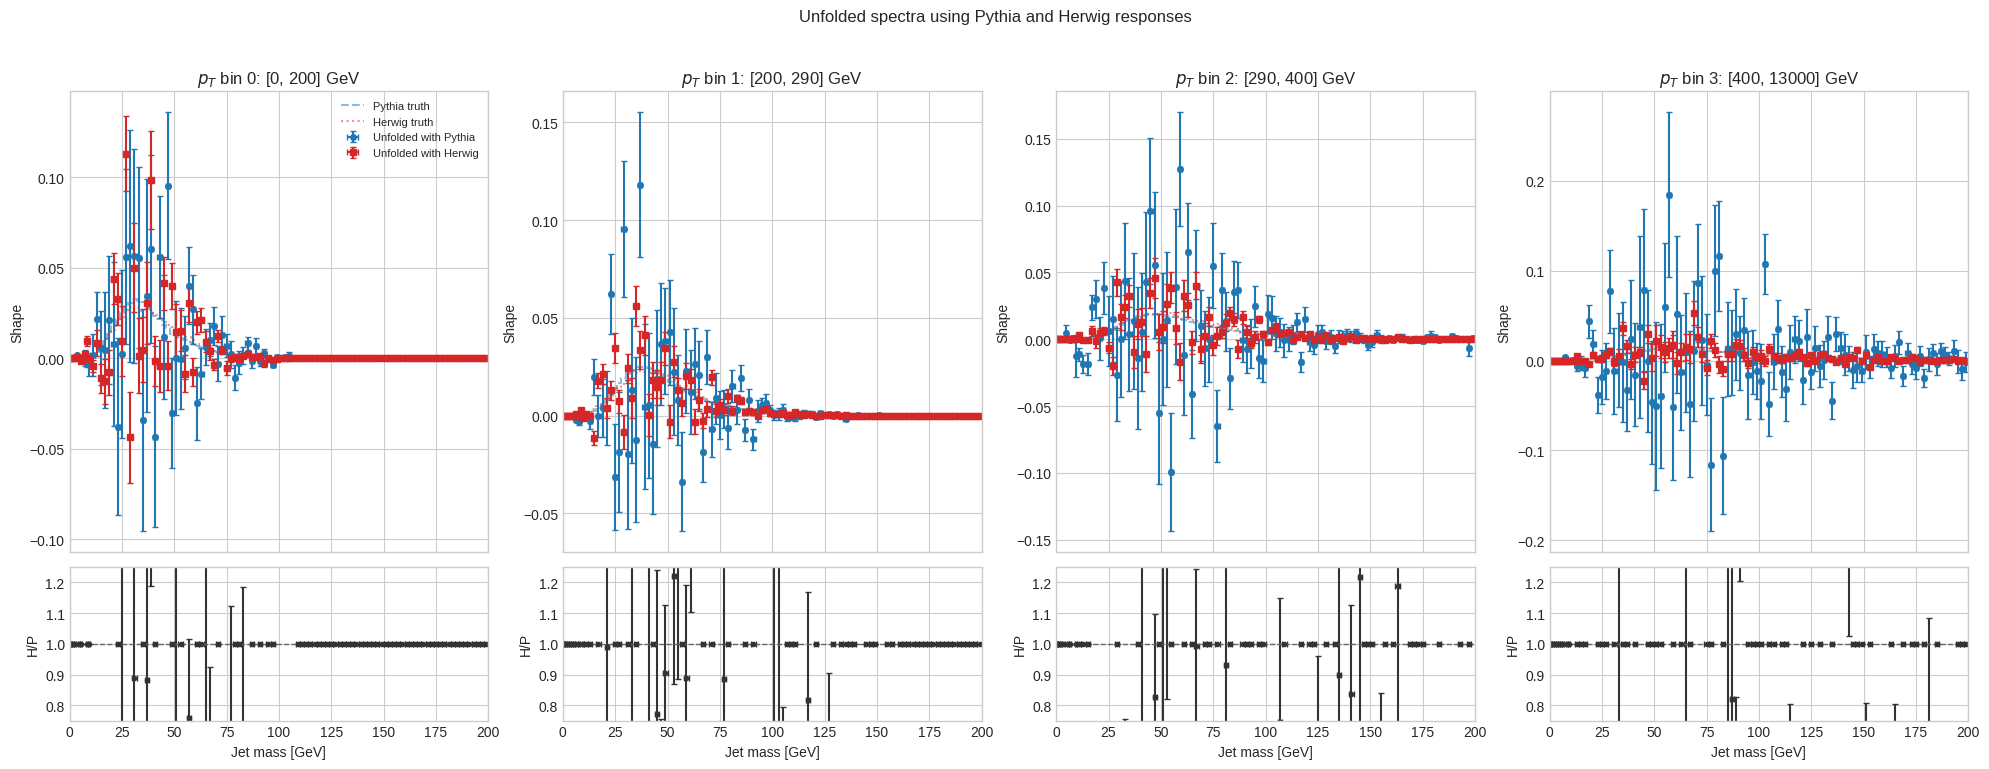

In [10]:
fig, axes = plt.subplots(
    2,
    n_ptgen,
    figsize=(5.0 * n_ptgen, 7.5),
    gridspec_kw={"height_ratios": [3.0, 1.0]},
    sharex="col",
)
if n_ptgen == 1:
    axes = np.asarray(axes).reshape(2, 1)

for pt_index in range(n_ptgen):
    ax_top = axes[0, pt_index]
    ax_ratio = axes[1, pt_index]

    pythia_values = results["pythia"]["unfolded_2d"][pt_index].copy()
    pythia_errors = results["pythia"]["unfolded_err_2d"][pt_index].copy()
    herwig_values = results["herwig"]["unfolded_2d"][pt_index].copy()
    herwig_errors = results["herwig"]["unfolded_err_2d"][pt_index].copy()
    pythia_truth = models["pythia"]["gen_2d"][pt_index].copy()
    herwig_truth = models["herwig"]["gen_2d"][pt_index].copy()

    if NORMALIZE_SHAPE_PLOTS:
        pythia_norm = np.sum(pythia_values * gen_mass_widths)
        herwig_norm = np.sum(herwig_values * gen_mass_widths)
        pythia_truth_norm = np.sum(pythia_truth * gen_mass_widths)
        herwig_truth_norm = np.sum(herwig_truth * gen_mass_widths)

        if pythia_norm > 0:
            pythia_values /= pythia_norm
            pythia_errors /= pythia_norm
        if herwig_norm > 0:
            herwig_values /= herwig_norm
            herwig_errors /= herwig_norm
        if pythia_truth_norm > 0:
            pythia_truth /= pythia_truth_norm
        if herwig_truth_norm > 0:
            herwig_truth /= herwig_truth_norm

    ax_top.errorbar(
        gen_mass_centers,
        pythia_values,
        yerr=pythia_errors,
        xerr=gen_mass_widths / 2.0,
        fmt="o",
        color=COLORS["pythia"],
        label="Unfolded with Pythia",
        ms=4,
        capsize=2,
    )
    ax_top.errorbar(
        gen_mass_centers,
        herwig_values,
        yerr=herwig_errors,
        xerr=gen_mass_widths / 2.0,
        fmt="s",
        color=COLORS["herwig"],
        label="Unfolded with Herwig",
        ms=4,
        capsize=2,
    )
    ax_top.step(
        gen_mass_edges[:-1],
        pythia_truth,
        where="post",
        color=COLORS["pythia"],
        alpha=0.5,
        linestyle="--",
        label="Pythia truth",
    )
    ax_top.step(
        gen_mass_edges[:-1],
        herwig_truth,
        where="post",
        color=COLORS["herwig"],
        alpha=0.5,
        linestyle=":",
        label="Herwig truth",
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.divide(herwig_values, pythia_values, out=np.ones_like(herwig_values), where=pythia_values > 0)
        ratio_err = np.divide(herwig_errors, pythia_values, out=np.zeros_like(herwig_errors), where=pythia_values > 0)

    ax_ratio.errorbar(
        gen_mass_centers,
        ratio,
        yerr=ratio_err,
        xerr=gen_mass_widths / 2.0,
        fmt="o",
        color="#333333",
        ms=3,
        capsize=2,
    )
    ax_ratio.axhline(1.0, color="#666666", linestyle="--", linewidth=1.0)
    ax_ratio.set_ylim(0.75, 1.25)

    pt_low = int(pt_edges[pt_index])
    pt_high = int(pt_edges[pt_index + 1]) if pt_index < n_ptgen - 1 else int(pt_edges[-1])
    ax_top.set_title(f"$p_T$ bin {pt_index}: [{pt_low}, {pt_high}] GeV")
    ax_top.set_xlim(gen_mass_edges[0], gen_mass_edges[-1])
    ax_ratio.set_xlim(gen_mass_edges[0], gen_mass_edges[-1])
    ax_ratio.set_xlabel(PLOT_OBSERVABLE_LABEL)
    ax_top.set_ylabel("Shape" if NORMALIZE_SHAPE_PLOTS else "Events")
    ax_ratio.set_ylabel("H/P")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Unfolded spectra using Pythia and Herwig responses", y=1.02)
plt.tight_layout()
plt.show()

## 7 — Regularisation Scan Diagnostics

The plots below are populated only when `REGULARIZATION_MODE` is `scan_tau` or `scan_lcurve`. In `none` mode the cell prints a short note instead.

In [11]:
if REGULARIZATION_MODE == "none":
    print("No scan diagnostic is shown because REGULARIZATION_MODE is 'none'.")
else:
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6.0 * len(MODEL_ORDER), 4.5))
    if len(MODEL_ORDER) == 1:
        axes = [axes]

    for axis, model_name in zip(axes, MODEL_ORDER):
        scan_payload = results[model_name]["scan"]
        chosen_tau = results[model_name]["tau"]

        if REGULARIZATION_MODE == "scan_tau":
            scan_result = sample_spline(scan_payload.get("scan_result"), np.log10(SCAN_TAU_MIN), np.log10(SCAN_TAU_MAX))
            if scan_result is not None:
                x_values, y_values = scan_result
                axis.plot(10.0 ** x_values, y_values, color=COLORS[model_name], linewidth=2.0)
                axis.axvline(chosen_tau, color="#444444", linestyle="--", linewidth=1.0)
                axis.set_xscale("log")
                axis.set_xlabel(r"$\tau$")
                axis.set_ylabel("Scan variable")
                axis.set_title(f"ScanTau: {model_name}")
        elif REGULARIZATION_MODE == "scan_lcurve":
            l_curve_points = tgraph_to_arrays(scan_payload.get("l_curve"))
            if l_curve_points is not None:
                x_values, y_values = l_curve_points
                axis.plot(x_values, y_values, marker="o", color=COLORS[model_name], linewidth=1.5)
                axis.set_xlabel(r"$\log_{10}(\chi_A^2)$")
                axis.set_ylabel(r"$\log_{10}(\chi_L^2)$")
                axis.set_title(f"L-curve: {model_name}")

                log_tau_x = scan_payload.get("log_tau_x")
                log_tau_y = scan_payload.get("log_tau_y")
                if log_tau_x and log_tau_y and chosen_tau > 0:
                    chosen_log_tau = np.log10(chosen_tau)
                    axis.scatter(
                        [log_tau_x.Eval(chosen_log_tau)],
                        [log_tau_y.Eval(chosen_log_tau)],
                        color="#111111",
                        zorder=5,
                        label=f"chosen $\\tau={chosen_tau:.3g}$",
                    )
                    axis.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

No scan diagnostic is shown because REGULARIZATION_MODE is 'none'.


## 8 — Folded-Back Spectra vs the Same Measured Reco Input

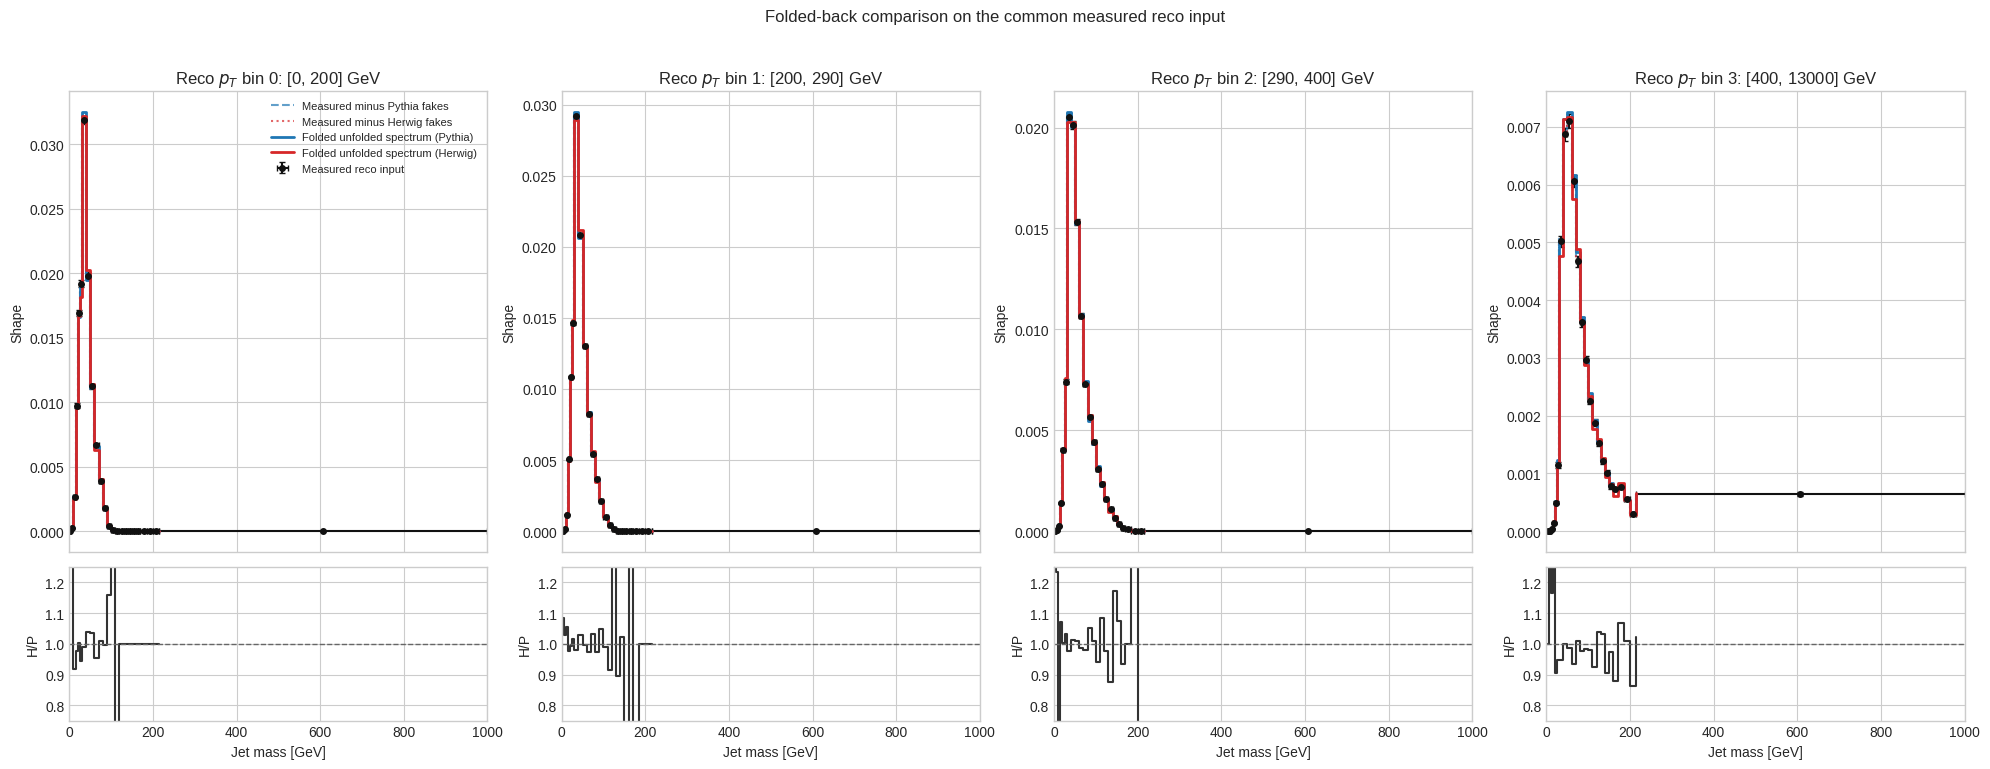

In [72]:
fig, axes = plt.subplots(
    2,
    n_ptreco,
    figsize=(5.0 * n_ptreco, 7.5),
    gridspec_kw={"height_ratios": [3.0, 1.0]},
    sharex="col",
)
if n_ptreco == 1:
    axes = np.asarray(axes).reshape(2, 1)

for pt_index in range(n_ptreco):
    ax_top = axes[0, pt_index]
    ax_ratio = axes[1, pt_index]

    raw_data = data_reco_values[pt_index].copy()
    raw_data_err = data_reco_errors[pt_index].copy()
    pythia_corrected = results["pythia"]["corrected_measurement_2d"][pt_index].copy()
    herwig_corrected = results["herwig"]["corrected_measurement_2d"][pt_index].copy()
    pythia_folded = results["pythia"]["folded_2d"][pt_index].copy()
    herwig_folded = results["herwig"]["folded_2d"][pt_index].copy()

    if NORMALIZE_SHAPE_PLOTS:
        raw_norm = np.sum(raw_data * reco_mass_widths)
        pythia_corr_norm = np.sum(pythia_corrected * reco_mass_widths)
        herwig_corr_norm = np.sum(herwig_corrected * reco_mass_widths)
        pythia_fold_norm = np.sum(pythia_folded * reco_mass_widths)
        herwig_fold_norm = np.sum(herwig_folded * reco_mass_widths)

        if raw_norm > 0:
            raw_data /= raw_norm
            raw_data_err /= raw_norm
        if pythia_corr_norm > 0:
            pythia_corrected /= pythia_corr_norm
        if herwig_corr_norm > 0:
            herwig_corrected /= herwig_corr_norm
        if pythia_fold_norm > 0:
            pythia_folded /= pythia_fold_norm
        if herwig_fold_norm > 0:
            herwig_folded /= herwig_fold_norm

    ax_top.errorbar(
        reco_mass_centers,
        raw_data,
        yerr=raw_data_err,
        xerr=reco_mass_widths / 2.0,
        fmt="o",
        color=COLORS["data"],
        label="Measured reco input",
        ms=4,
        capsize=2,
    )
    ax_top.step(
        reco_mass_edges[:-1],
        pythia_corrected,
        where="post",
        color=COLORS["pythia"],
        linestyle="--",
        alpha=0.7,
        label="Measured minus Pythia fakes",
    )
    ax_top.step(
        reco_mass_edges[:-1],
        herwig_corrected,
        where="post",
        color=COLORS["herwig"],
        linestyle=":",
        alpha=0.7,
        label="Measured minus Herwig fakes",
    )
    ax_top.step(
        reco_mass_edges[:-1],
        pythia_folded,
        where="post",
        color=COLORS["pythia"],
        linewidth=2.0,
        label="Folded unfolded spectrum (Pythia)",
    )
    ax_top.step(
        reco_mass_edges[:-1],
        herwig_folded,
        where="post",
        color=COLORS["herwig"],
        linewidth=2.0,
        label="Folded unfolded spectrum (Herwig)",
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.divide(herwig_folded, pythia_folded, out=np.ones_like(herwig_folded), where=pythia_folded > 0)
    ax_ratio.step(reco_mass_edges[:-1], ratio, where="post", color="#333333")
    ax_ratio.axhline(1.0, color="#666666", linestyle="--", linewidth=1.0)
    ax_ratio.set_ylim(0.75, 1.25)

    pt_low = int(models["pythia"]["ptreco_edges"][pt_index])
    pt_high = int(models["pythia"]["ptreco_edges"][pt_index + 1]) if pt_index < n_ptreco - 1 else int(models["pythia"]["ptreco_edges"][-1])
    ax_top.set_title(f"Reco $p_T$ bin {pt_index}: [{pt_low}, {pt_high}] GeV")
    ax_top.set_xlim(reco_mass_edges[0], reco_mass_edges[-1])
    ax_ratio.set_xlim(reco_mass_edges[0], reco_mass_edges[-1])
    ax_top.set_ylabel("Shape" if NORMALIZE_SHAPE_PLOTS else "Events")
    ax_ratio.set_ylabel("H/P")
    ax_ratio.set_xlabel(PLOT_OBSERVABLE_LABEL)

axes[0, 0].legend(fontsize=8)
fig.suptitle("Folded-back comparison on the common measured reco input", y=1.02)
plt.tight_layout()
plt.show()

## 9 — Response Matrix Diagnostics

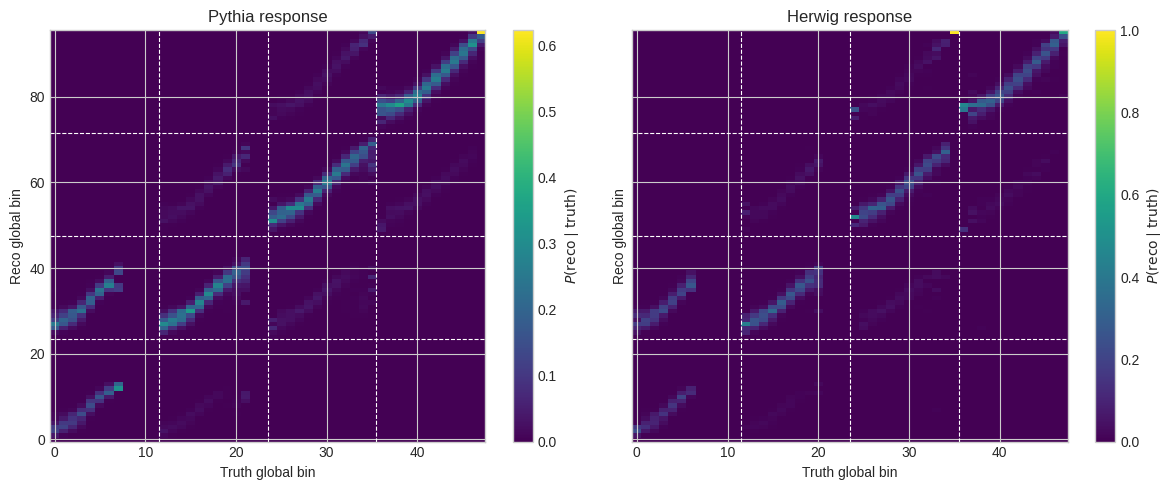

In [73]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6.0 * len(MODEL_ORDER), 5.0), sharex=True, sharey=True)
if len(MODEL_ORDER) == 1:
    axes = [axes]

for axis, model_name in zip(axes, MODEL_ORDER):
    response = models[model_name]["response_2d"]
    truth_sums = response.sum(axis=0, keepdims=True)
    truth_sums[truth_sums == 0.0] = 1.0
    probability = response / truth_sums

    image = axis.imshow(
        probability,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        norm=mcolors.Normalize(vmin=0.0, vmax=np.nanmax(probability)),
    )

    for index in range(1, models[model_name]["n_ptgen"]):
        axis.axvline(index * models[model_name]["n_mgen"] - 0.5, color="white", linestyle="--", linewidth=0.8)
    for index in range(1, models[model_name]["n_ptreco"]):
        axis.axhline(index * models[model_name]["n_mreco"] - 0.5, color="white", linestyle="--", linewidth=0.8)

    axis.set_title(f"{model_name.capitalize()} response")
    axis.set_xlabel("Truth global bin")
    axis.set_ylabel("Reco global bin")
    plt.colorbar(image, ax=axis, label=r"$P(\mathrm{reco}\mid\mathrm{truth})$")

plt.tight_layout()
plt.show()

## 10 — Fake and Miss Diagnostics

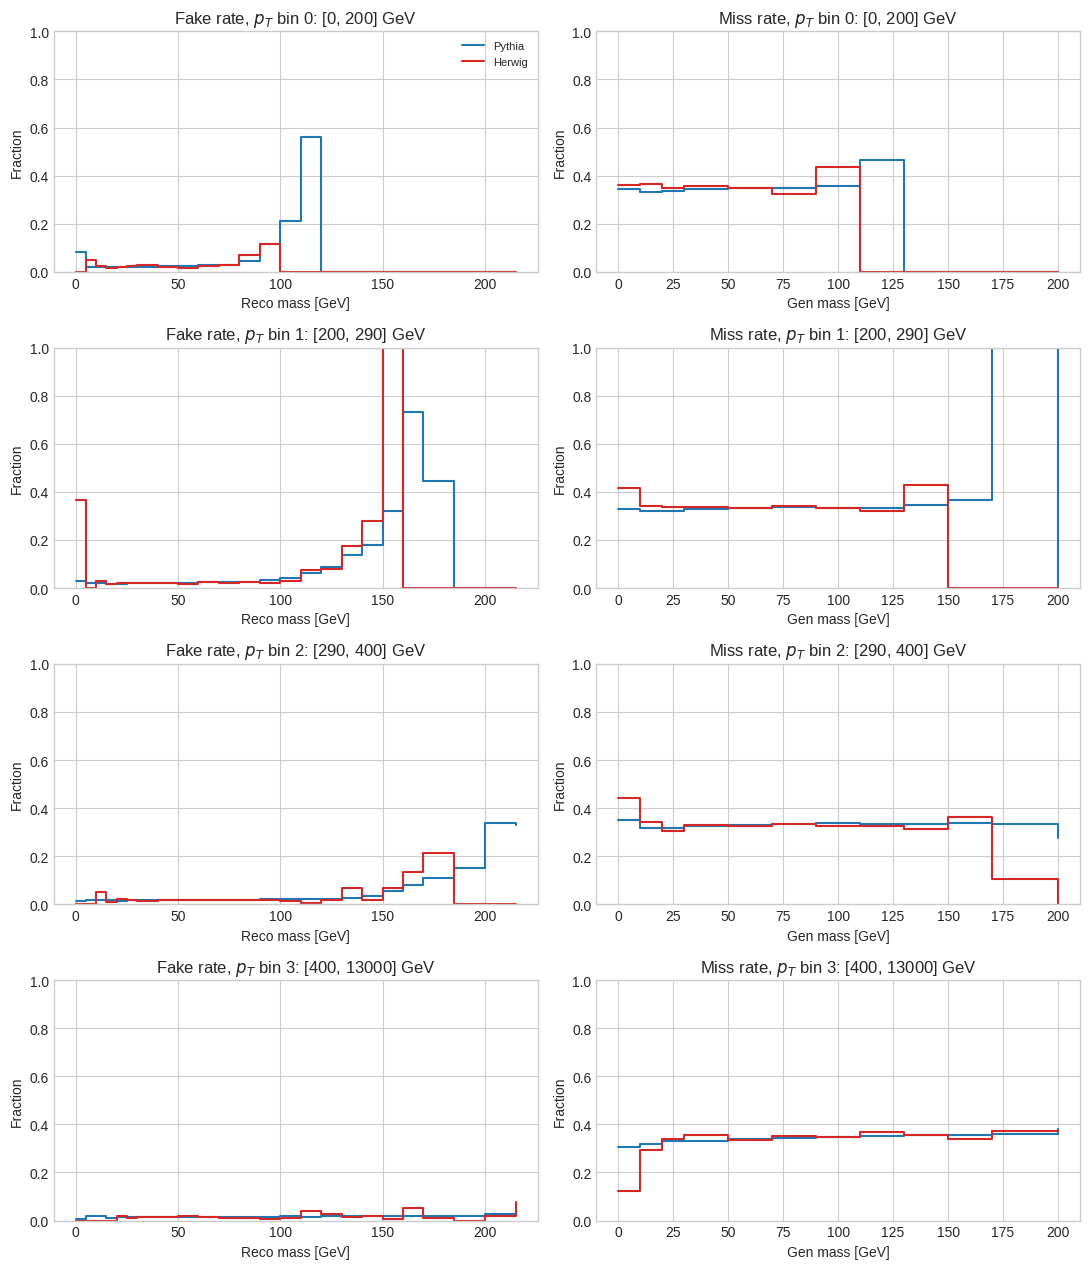

In [74]:
fig, axes = plt.subplots(n_ptgen, 2, figsize=(11.0, 3.2 * n_ptgen), sharex=False)
if n_ptgen == 1:
    axes = np.asarray(axes).reshape(1, 2)

for pt_index in range(n_ptgen):
    fake_axis = axes[pt_index, 0]
    miss_axis = axes[pt_index, 1]

    for model_name in MODEL_ORDER:
        model = models[model_name]
        fake_rate = np.divide(
            model["fakes_2d"][pt_index],
            model["reco_2d"][pt_index],
            out=np.zeros_like(model["fakes_2d"][pt_index]),
            where=model["reco_2d"][pt_index] > 0,
        )
        miss_rate = np.divide(
            model["misses_2d"][pt_index],
            model["gen_2d"][pt_index],
            out=np.zeros_like(model["misses_2d"][pt_index]),
            where=model["gen_2d"][pt_index] > 0,
        )

        fake_axis.step(reco_mass_edges[:-1], fake_rate, where="post", color=COLORS[model_name], label=model_name.capitalize())
        miss_axis.step(gen_mass_edges[:-1], miss_rate, where="post", color=COLORS[model_name], label=model_name.capitalize())

    pt_low = int(pt_edges[pt_index])
    pt_high = int(pt_edges[pt_index + 1]) if pt_index < n_ptgen - 1 else int(pt_edges[-1])
    fake_axis.set_title(f"Fake rate, $p_T$ bin {pt_index}: [{pt_low}, {pt_high}] GeV")
    miss_axis.set_title(f"Miss rate, $p_T$ bin {pt_index}: [{pt_low}, {pt_high}] GeV")
    fake_axis.set_ylim(0.0, 1.0)
    miss_axis.set_ylim(0.0, 1.0)
    fake_axis.set_xlabel("Reco mass [GeV]")
    miss_axis.set_xlabel("Gen mass [GeV]")
    fake_axis.set_ylabel("Fraction")
    miss_axis.set_ylabel("Fraction")

axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11 — Covariance and Correlation Comparison

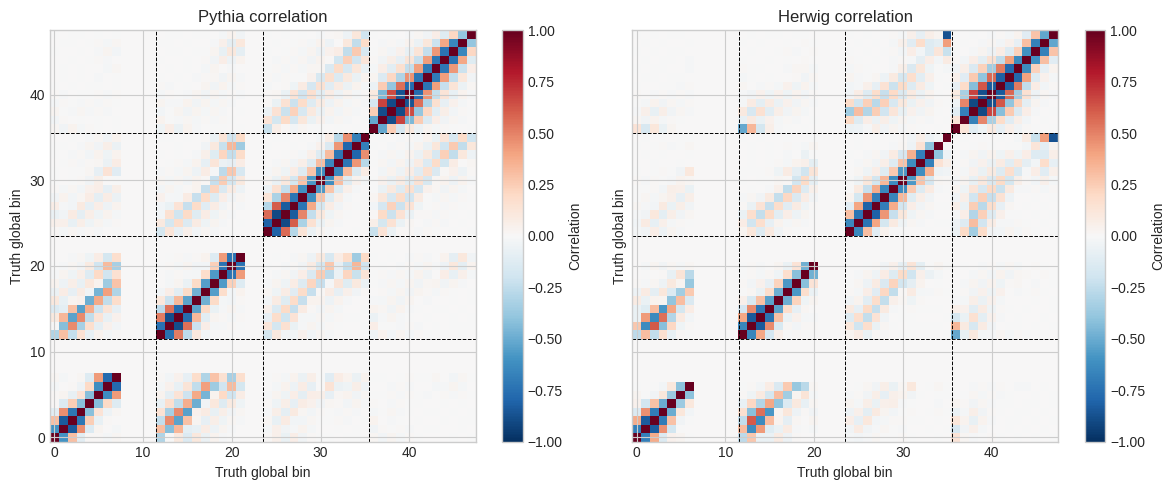

In [75]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6.0 * len(MODEL_ORDER), 5.0), sharex=True, sharey=True)
if len(MODEL_ORDER) == 1:
    axes = [axes]

for axis, model_name in zip(axes, MODEL_ORDER):
    image = axis.imshow(
        results[model_name]["correlation"],
        origin="lower",
        aspect="auto",
        cmap="RdBu_r",
        vmin=-1.0,
        vmax=1.0,
    )
    for index in range(1, n_ptgen):
        axis.axvline(index * n_mgen - 0.5, color="black", linestyle="--", linewidth=0.7)
        axis.axhline(index * n_mgen - 0.5, color="black", linestyle="--", linewidth=0.7)
    axis.set_title(f"{model_name.capitalize()} correlation")
    axis.set_xlabel("Truth global bin")
    axis.set_ylabel("Truth global bin")
    plt.colorbar(image, ax=axis, label="Correlation")

plt.tight_layout()
plt.show()

## 12 — Summary

In [76]:
print("=" * 72)
print("2D unfolding summary")
print("=" * 72)
print(f"Observable           : {'ungroomed' if OBS == 'u' else 'groomed'} mass")
print(f"Regularization mode  : {REGULARIZATION_MODE}")
print(f"Fixed tau            : {FIXED_TAU}")
print(f"Scan range           : [{SCAN_TAU_MIN}, {SCAN_TAU_MAX}] with {SCAN_N_POINTS} points")
print(f"Fake subtraction     : {USE_FAKE_BACKGROUND_SUBTRACTION}")
print(f"Measured reco total  : {data_reco_flat.sum():.3f}")
print()

for model_name in MODEL_ORDER:
    model = models[model_name]
    result = results[model_name]
    print(f"[{model_name.upper()}]")
    print(f"  tau                : {result['tau']:.6g}")
    print(f"  status             : {result['status']}")
    print(f"  chi2A              : {result['chi2_a']:.4f}")
    print(f"  chi2L              : {result['chi2_l']:.4f}")
    print(f"  rho_avg            : {result['rho_avg']:.4f}")
    print(f"  total fakes        : {model['fakes_flat'].sum():.3f}")
    print(f"  total misses       : {model['misses_flat'].sum():.3f}")
    print(f"  unfolded integral  : {result['unfolded_flat'].sum():.3f}")
    print("  unfolded per pt bin:")
    for pt_index in range(model['n_ptgen']):
        pt_low = int(model['ptgen_edges'][pt_index])
        pt_high = int(model['ptgen_edges'][pt_index + 1]) if pt_index < model['n_ptgen'] - 1 else int(model['ptgen_edges'][-1])
        integral = result['unfolded_2d'][pt_index].sum()
        print(f"    bin {pt_index}: [{pt_low}, {pt_high}] GeV -> {integral:.3f}")
    print()

print("=" * 72)

2D unfolding summary
Observable           : ungroomed mass
Regularization mode  : none
Fixed tau            : 0.0
Scan range           : [1e-06, 1.0] with 40 points
Fake subtraction     : True
Measured reco total  : 372041.000

[PYTHIA]
  tau                : 0
  status             : 18
  chi2A              : 85.1693
  chi2L              : 0.0000
  rho_avg            : 0.8743
  total fakes        : 6629.081
  total misses       : 153611.698
  unfolded integral  : 547814.314
  unfolded per pt bin:
    bin 0: [0, 200] GeV -> 120710.948
    bin 1: [200, 290] GeV -> 309430.638
    bin 2: [290, 400] GeV -> 83880.540
    bin 3: [400, 13000] GeV -> 33792.188

[HERWIG]
  tau                : 0
  status             : 18
  chi2A              : 570.8050
  chi2L              : 0.0000
  rho_avg            : 0.8394
  total fakes        : 11.091
  total misses       : 270.530
  unfolded integral  : 562791.265
  unfolded per pt bin:
    bin 0: [0, 200] GeV -> 122544.437
    bin 1: [200, 290] GeV -> 32

## 13 — Main Objects

In [77]:
artifacts = {
    "config": {
        "OBS": OBS,
        "INPUT_FILES": INPUT_FILES,
        "REGULARIZATION_MODE": REGULARIZATION_MODE,
        "FIXED_TAU": FIXED_TAU,
        "SCAN_N_POINTS": SCAN_N_POINTS,
        "SCAN_TAU_MIN": SCAN_TAU_MIN,
        "SCAN_TAU_MAX": SCAN_TAU_MAX,
        "USE_FAKE_BACKGROUND_SUBTRACTION": USE_FAKE_BACKGROUND_SUBTRACTION,
    },
    "data_reco_values": data_reco_values,
    "data_reco_errors": data_reco_errors,
    "models": models,
    "results": results,
}

artifacts.keys()

dict_keys(['config', 'data_reco_values', 'data_reco_errors', 'models', 'results'])